In [1]:
import numpy as np
import pyxdf
import pandas as pd
import mne
import matplotlib.pyplot as plt
import os

In [3]:
data, header = pyxdf.load_xdf("../lab_recorder_data/sub-scott_sham1_ses-scott_sham1_task-Default_run-001_eeg.xdf")
data

[{'info': defaultdict(list,
              {'name': ['PsychoPyMarkers'],
               'type': ['Markers'],
               'channel_count': ['1'],
               'channel_format': ['string'],
               'source_id': ['-4379379051682882619'],
               'nominal_srate': ['0.000000000000000'],
               'version': ['1.100000000000000'],
               'created_at': ['2126654.882835100'],
               'uid': ['443a876e-6c81-4320-b1c4-53fc740472e4'],
               'session_id': ['default'],
               'hostname': ['JanetsPC'],
               'v4address': [None],
               'v4data_port': ['16575'],
               'v4service_port': ['16580'],
               'v6address': [None],
               'v6data_port': ['16575'],
               'v6service_port': ['16580'],
               'desc': [None],
               'stream_id': 1,
               'effective_srate': 0,
               'segments': [(0, 99)],
               'clock_segments': [(0, 99)]}),
  'footer': {'info': defau

In [13]:
stream = data[3]
df= []
df = pd.DataFrame(stream['time_series'])
df = df.rename(columns={i: f"Ch{i}" for i in range(df.shape[1])})

# Add timestamp column
df['Timestamp'] = stream['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in df.columns if col != 'Timestamp']
df = df[cols]
eeg_raw = df[['Ch0', 'Ch1', 'Ch2', 'Ch3', 'Ch4', 'Ch5', 'Ch6', 'Ch12','Timestamp']]
eeg_raw

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch12,Timestamp
0,42082.648438,20786.525391,10384.942383,13134.862305,32778.500000,50584.773438,56421.093750,-0.415687,2.126672e+06
1,41866.519531,20716.193359,10511.184570,13218.117188,32831.218750,50300.460938,56478.835938,-0.546212,2.126672e+06
2,42414.187500,21033.291016,10112.310547,12833.953125,32569.150391,50980.550781,56422.710938,-0.594477,2.126672e+06
3,42800.429688,21225.953125,9883.427734,12634.445312,32442.240234,51498.230469,56354.480469,-0.494768,2.126672e+06
4,42137.511719,20810.130859,10316.659180,13035.036133,32732.417969,50667.148438,56380.113281,-0.295945,2.126672e+06
...,...,...,...,...,...,...,...,...,...
57541,41172.554688,20478.896484,9971.596680,13088.465820,32628.464844,39031.148438,56847.699219,-0.062478,2.126902e+06
57542,41571.050781,20707.964844,9636.474609,12801.934570,32424.740234,39632.136719,56720.281250,-0.095029,2.126902e+06
57543,40984.707031,20331.552734,10063.195312,13272.833984,32685.687500,38858.843750,56758.242188,-0.130580,2.126902e+06
57544,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.747336,2.126902e+06


In [9]:
EEG_LIFU_events = data[1]

# Create DataFrame from time_series
markers = pd.DataFrame(EEG_LIFU_events['time_series'])

# Rename the first column to 'markers'
markers.rename(columns={0: 'markers'}, inplace=True)

# Add timestamp column
markers['Timestamp'] = EEG_LIFU_events['time_stamps']

# Move Timestamp to be the first column after the index
cols = ['Timestamp'] + [col for col in markers.columns if col != 'Timestamp']
markers = markers[cols]
markers

,Timestamp,markers
0,2.126684e+06,START_EXPERIMENT_RECEIVED
1,2.126685e+06,LIFU_ON
2,2.126690e+06,LIFU_OFF
3,2.126702e+06,LIFU_ON
4,2.126707e+06,LIFU_OFF
5,2.126722e+06,LIFU_ON
6,2.126727e+06,LIFU_OFF
7,2.126737e+06,LIFU_ON
8,2.126742e+06,LIFU_OFF
9,2.126752e+06,LIFU_ON


In [10]:
lifu_on = markers[markers['markers'] == 'LIFU_ON']
lifu_on = np.array(lifu_on['Timestamp'])
lifu_on

array([2126684.8026258 , 2126701.73062089, 2126721.61227271,
       2126736.73185857, 2126752.12881684, 2126768.73627831,
       2126786.04525023, 2126802.6570825 , 2126817.73118836,
       2126833.77098548, 2126850.41133355])

In [60]:
# windowing around LIFU Onset
pre = 2
post = 7
raw_windows = []
target_ts_onset = lifu_on
raw = eeg_raw

for idx, event in enumerate(lifu_on): 
    mask = (raw['Timestamp'] >= (event - pre)) & (raw['Timestamp'] <= (event + post))
    window_df = raw.loc[mask].copy()
    window_df["t_rel"] = window_df["Timestamp"] - event 
    window_df["idx"] = idx
    raw_windows.append(window_df)
raw_windows[5]

,Ch0,Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch12,Timestamp,t_rel,idx
23705,40616.679688,21193.150391,10240.317383,5482.889160,32726.865234,50799.375000,56828.292969,0.403107,2.126767e+06,-1.996286,5
23706,41079.210938,21552.302734,9797.763672,5079.984375,32423.761719,51631.617188,56659.417969,0.317688,2.126767e+06,-1.992285,5
23707,40960.105469,21439.052734,9907.794922,5249.476562,32511.449219,51507.738281,56635.312500,0.191200,2.126767e+06,-1.988285,5
23708,40318.925781,20943.855469,10451.914062,5773.974121,32899.429688,50401.687500,56815.675781,0.045402,2.126767e+06,-1.984285,5
23709,40498.050781,21099.521484,10307.742188,5585.193848,32779.335938,50628.304688,56837.585938,-0.088982,2.126767e+06,-1.980285,5
...,...,...,...,...,...,...,...,...,...,...,...
25949,40668.656250,21210.603516,9885.216797,4561.949219,32453.730469,51251.843750,56529.312500,-0.139554,2.126776e+06,6.980106,5
25950,40180.375000,20822.552734,10347.583008,4985.356934,32784.960938,50319.960938,56724.582031,-0.064150,2.126776e+06,6.984106,5
25951,40447.261719,21051.599609,10137.416992,4730.749023,32621.171875,50704.011719,56723.699219,0.041147,2.126776e+06,6.988106,5
25952,40924.000000,21418.384766,9697.629883,4317.832031,32310.728516,51556.832031,56555.800781,0.202672,2.126776e+06,6.992106,5


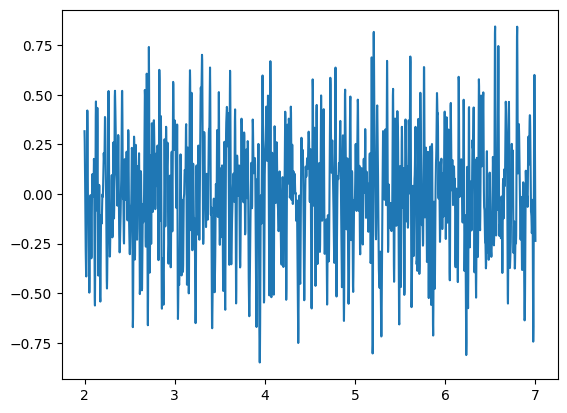

In [50]:
# won't look like anything since i didn't sonicate
channel_8 = np.array(raw_windows[0]['Ch12'])
n = len(channel_8)   
t = np.linspace(pre, post, n)
plt.plot(t, channel_8)

In [52]:
import numpy as np
import mne

sfreq = 250

all_epochs = []

for idx in range(len(raw_windows)):
    df = raw_windows[idx].copy()
    df.columns = df.columns.str.strip()

    # Drop non‑EEG columns
    df = df.drop(['Timestamp', 't_rel', 'idx', 'Ch12'], axis=1)

    # Convert to numpy (n_channels × n_times)
    data = df.to_numpy().T

    all_epochs.append(data)

# Stack into shape (n_epochs, n_channels, n_times)
all_epochs = np.stack(all_epochs, axis=0)

# Channel names and types
ch_names = list(df.columns)
ch_types = ['eeg'] * len(ch_names)

# Create info
info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)

# Create MNE Epochs object
epochs = mne.EpochsArray(all_epochs, info)


ValueError: all input arrays must have the same shape